# 3. Baseline del Proceso de Pasteurización

Métricas de rendimiento energético y productivo actuales (control PID) como referencia para la optimización con Red Neuronal + Algoritmo Genético.

| Métrica | Descripción | Unidad |
|:---|:---|:---|
| **E_consumo** | Consumo energético instantáneo | kW |
| **F_flow** | Caudal de producción | L/h |
| **T_out_leche** | Temperatura de salida de la leche | °C |
| **T_servicio** | Temperatura del agua de servicio (caldera) | °C |
| **E/F** | Consumo específico = $E_{consumo} / F_{flow}$ | kW/(L/h) |
| **Margen** | $T_{out} - 72°C$ (seguridad térmica) | °C |

El Algoritmo genético debe encontrar una configuración tal que disminuya un 20% el consumo energético de la planta.

Esta celda se ha escrito una vez se han realizado el proyecto

> **Objetivo GA v1:** Minimizar $E_{consumo}$ manteniendo $T_{out} \ge 72°C$

> **Objetivo GA v2:** Minimizar $E_{consumo}$ y maximizar $F_{flow}$ manteniendo $T_{out} \ge 72°C$ — criterio de selección: min $E/F$

In [1]:
# --- Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
COLORS = ["#004c6d", "#588c7e", "#ffcc5c", "#c83349"]
sns.set_palette(sns.color_palette(COLORS))

# Constantes — alineadas con notebooks de optimización GA
T_SEGURIDAD = 72.0          # °C — restricción de seguridad alimentaria
FREQ_MIN = 5                # min — frecuencia de muestreo
F_FLOW_BOUNDS = (3500, 5500)   # L/h — bounds del GA
T_SERV_BOUNDS = (76, 95)       # °C — bounds del GA

RUTA_DATOS   = Path('../../data/raw/pasteurizacion_dataset_simulado.csv')
RUTA_METRICAS = Path('../../models/metrics/baseline_metrics.json')
RUTA_GA_V1   = Path('../../models/metrics/ga_optimization_report.json')
RUTA_GA_V2   = Path('../../models/metrics/ga_v2_optimization_report.json')

# --- Carga de datos (solo producción, excluye CIP) ---
df = pd.read_csv(RUTA_DATOS)
df_prod = df[df['Is_Cleaning'] == 0].copy()
df_prod['Time_d'] = df_prod['Time_min'] / (60 * 24)
dt_h = FREQ_MIN / 60  # horas por registro

# Métricas instantáneas alineadas con GA
df_prod['E_over_F'] = df_prod['E_consumo'] / df_prod['F_flow']  # kW/(L/h)
df_prod['margen'] = df_prod['T_out_leche'] - T_SEGURIDAD         # °C

print(f"Dataset: {len(df_prod):,} registros de producción | {df_prod['Time_d'].max():.0f} días")
print(f"Variables clave: E_consumo (kW), F_flow (L/h), T_out_leche (°C), T_servicio (°C)")
print(f"Métrica derivada: E/F = E_consumo / F_flow (kW/(L/h))")

Dataset: 51,404 registros de producción | 180 días
Variables clave: E_consumo (kW), F_flow (L/h), T_out_leche (°C), T_servicio (°C)
Métrica derivada: E/F = E_consumo / F_flow (kW/(L/h))


## 3.1 KPIs de Producción y Consumo Energético

Calculamos las métricas de referencia del proceso actual (PID) usando las **mismas variables y unidades** que los algoritmos de optimización GA v1/v2.

In [2]:
# ── KPIs alineados con GA v1/v2 ──────────────────────────────────────────────

# Consumo
E_mean     = df_prod['E_consumo'].mean()
E_std      = df_prod['E_consumo'].std()
E_total_kwh = (df_prod['E_consumo'] * dt_h).sum()

# Producción
F_mean     = df_prod['F_flow'].mean()
F_std      = df_prod['F_flow'].std()
vol_total  = (df_prod['F_flow'] * dt_h).sum()

# Consumo específico E/F  (métrica principal del GA v2)
EF_mean    = df_prod['E_over_F'].mean()
EF_std     = df_prod['E_over_F'].std()

# Temperatura servicio (variable controlable optimizada por el GA)
Ts_mean    = df_prod['T_servicio'].mean()
Ts_std     = df_prod['T_servicio'].std()

# Seguridad térmica
T_out_mean = df_prod['T_out_leche'].mean()
T_out_min  = df_prod['T_out_leche'].min()
margen_medio = T_out_mean - T_SEGURIDAD
tasa_cumplimiento = (df_prod['T_out_leche'] >= T_SEGURIDAD).mean() * 100

# ── Presentación ──
print("=" * 60)
print("  BASELINE (Test Set) — MÉTRICAS DE REFERENCIA (PID)")
print("=" * 60)

print(f"\n  CONSUMO ENERGÉTICO")
print(f"    E_consumo medio:       {E_mean:.2f} ± {E_std:.2f} kW")
print(f"    E_consumo total:       {E_total_kwh:,.0f} kWh")

print(f"\n  PRODUCCIÓN")
print(f"    F_flow medio:          {F_mean:.1f} ± {F_std:.1f} L/h")
print(f"    Volumen total:         {vol_total:,.0f} L")

print(f"\n  EFICIENCIA  (métrica GA v2)")
print(f"    E/F medio:             {EF_mean:.5f} kW/(L/h)")

print(f"\n  CALDERA")
print(f"    T_servicio media:      {Ts_mean:.2f} ± {Ts_std:.2f} °C")

print(f"\n  SEGURIDAD TÉRMICA")
print(f"    T_out media:           {T_out_mean:.2f} °C  (margen: +{margen_medio:.2f} °C)")
print(f"    T_out mínima:          {T_out_min:.2f} °C")
print(f"    Cumplimiento ≥72°C:    {tasa_cumplimiento:.1f} %")
print("=" * 60)

  BASELINE (Test Set) — MÉTRICAS DE REFERENCIA (PID)

  CONSUMO ENERGÉTICO
    E_consumo medio:       429.63 ± 17.64 kW
    E_consumo total:       1,840,384 kWh

  PRODUCCIÓN
    F_flow medio:          5000.5 ± 100.5 L/h
    Volumen total:         21,420,634 L

  EFICIENCIA  (métrica GA v2)
    E/F medio:             0.08592 kW/(L/h)

  CALDERA
    T_servicio media:      82.92 ± 0.83 °C

  SEGURIDAD TÉRMICA
    T_out media:           73.50 °C  (margen: +1.50 °C)
    T_out mínima:          73.01 °C
    Cumplimiento ≥72°C:    100.0 %


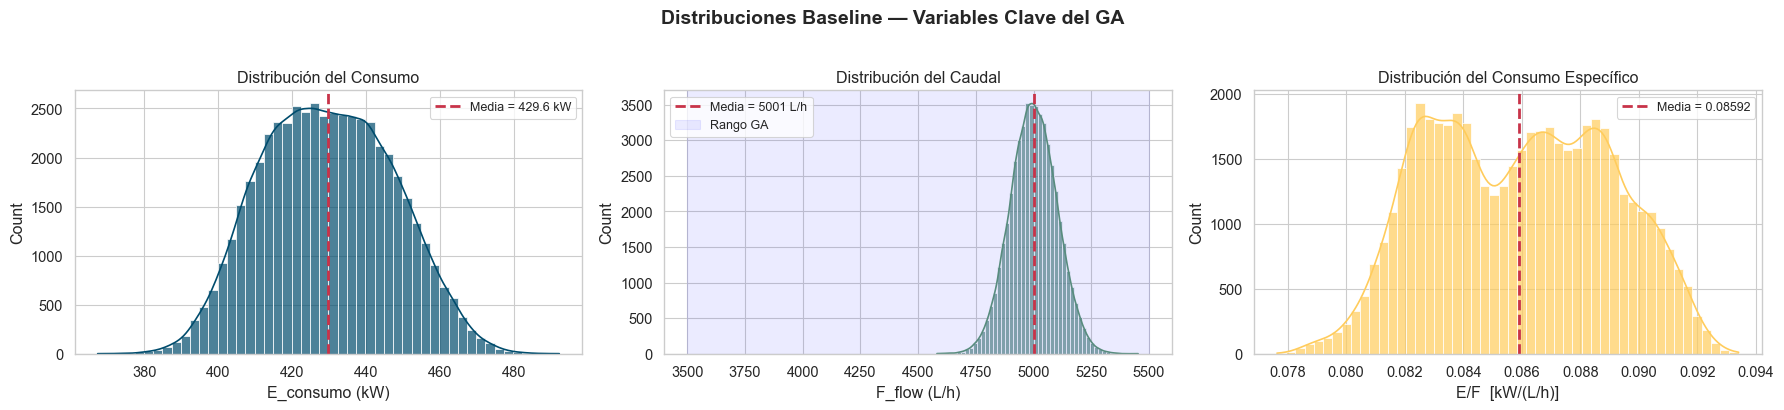

In [3]:
# ── Distribuciones: E_consumo, F_flow, E/F ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Distribución E_consumo
sns.histplot(df_prod['E_consumo'], bins=50, kde=True, ax=axes[0], color=COLORS[0], alpha=0.7)
axes[0].axvline(E_mean, color=COLORS[3], ls='--', lw=2, label=f'Media = {E_mean:.1f} kW')
axes[0].set_xlabel('E_consumo (kW)')
axes[0].set_title('Distribución del Consumo')
axes[0].legend(fontsize=9)

# 2. Distribución F_flow
sns.histplot(df_prod['F_flow'], bins=50, kde=True, ax=axes[1], color=COLORS[1], alpha=0.7)
axes[1].axvline(F_mean, color=COLORS[3], ls='--', lw=2, label=f'Media = {F_mean:.0f} L/h')
axes[1].axvspan(F_FLOW_BOUNDS[0], F_FLOW_BOUNDS[1], alpha=0.08, color='blue', label='Rango GA')
axes[1].set_xlabel('F_flow (L/h)')
axes[1].set_title('Distribución del Caudal')
axes[1].legend(fontsize=9)

# 3. Distribución E/F (consumo específico)
sns.histplot(df_prod['E_over_F'], bins=50, kde=True, ax=axes[2], color=COLORS[2], alpha=0.7)
axes[2].axvline(EF_mean, color=COLORS[3], ls='--', lw=2, label=f'Media = {EF_mean:.5f}')
axes[2].set_xlabel('E/F  [kW/(L/h)]')
axes[2].set_title('Distribución del Consumo Específico')
axes[2].legend(fontsize=9)

plt.suptitle('Distribuciones Baseline — Variables Clave del GA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación de las distribuciones:**

1. **E_consumo (izquierda):** Distribución aproximadamente simétrica con dispersión considerable (~300-500 kW), coherente con la fuerte influencia de `T_in_leche` (r = −0.83). El rango refleja la variabilidad estacional.

2. **F_flow (centro):** El caudal de producción presenta su propia distribución dentro del rango operativo. Esta es la **variable productiva** que el GA v2 busca maximizar (a 5500 L/h) en lugar de sacrificar como hacía v1 (reducía a 3500 L/h).

3. **E/F — Consumo Específico (derecha):** La métrica de eficiencia que equilibra consumo y producción. Es el **criterio de selección del GA v2**: min $E_{consumo}/F_{flow}$. Su distribución indica la eficiencia típica del proceso PID actual.

C:\Users\vgarc\AppData\Local\Temp\ipykernel_15060\2043629750.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_prod, x='fase_ciclo', y='E_consumo', ax=axes[1, 1],


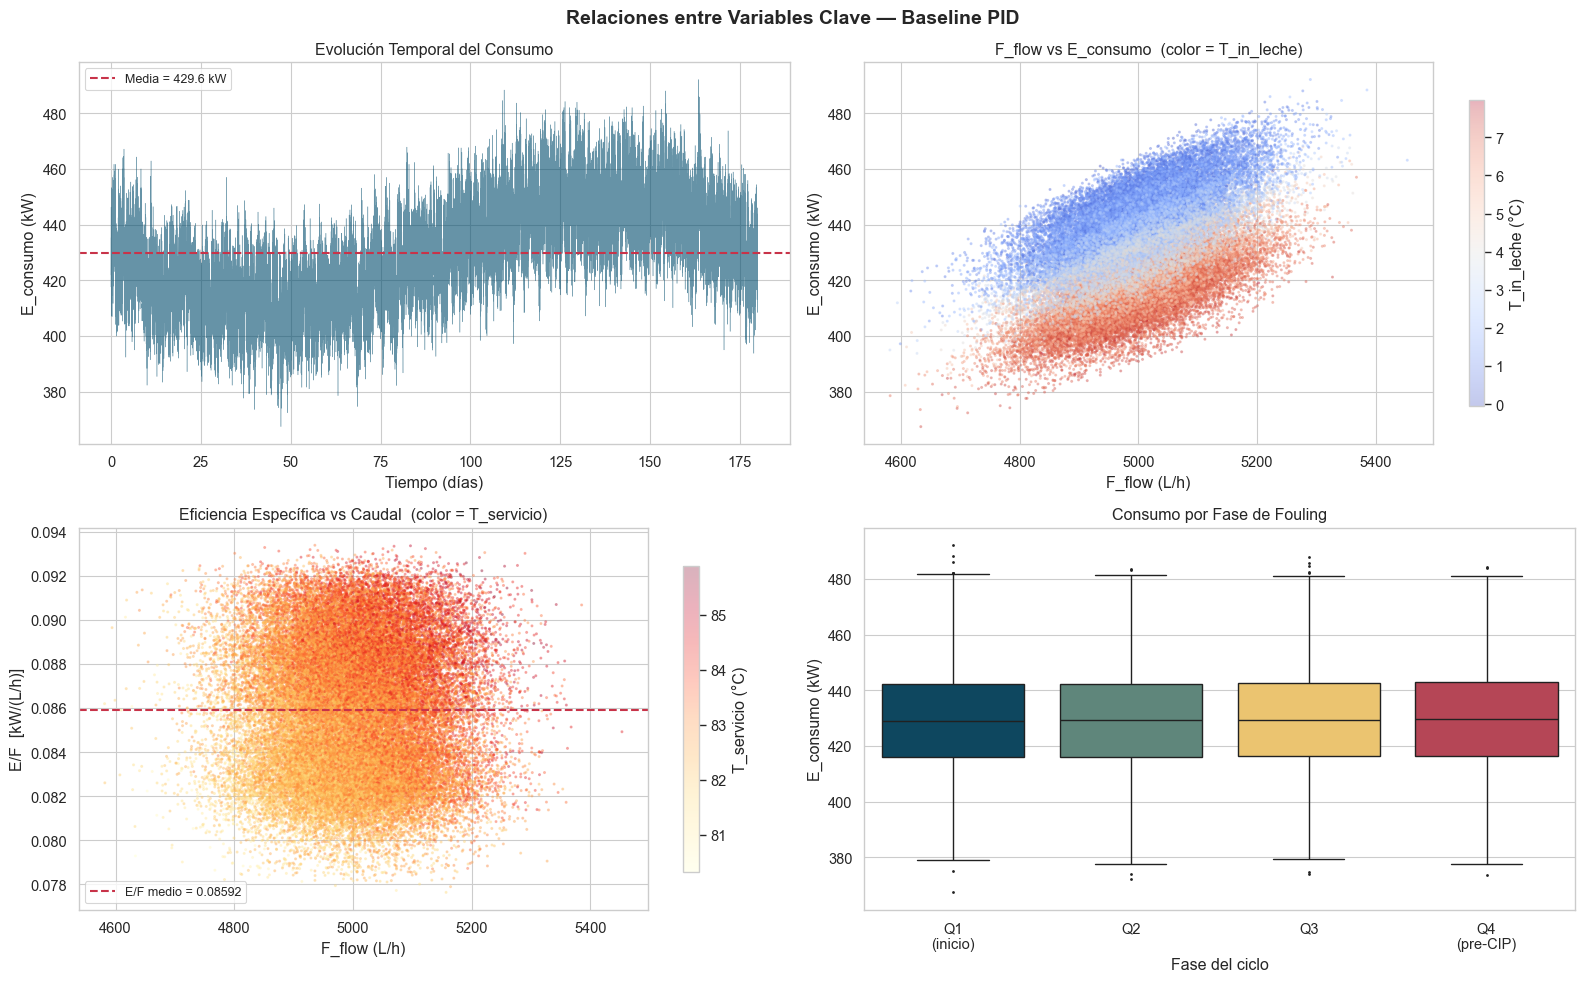

In [4]:
# ── Panel 2x2: relaciones entre variables clave ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Serie temporal E_consumo
axes[0, 0].plot(df_prod['Time_d'], df_prod['E_consumo'], lw=0.3, alpha=0.6, color=COLORS[0])
axes[0, 0].axhline(E_mean, color=COLORS[3], ls='--', lw=1.5, label=f'Media = {E_mean:.1f} kW')
axes[0, 0].set_xlabel('Tiempo (días)')
axes[0, 0].set_ylabel('E_consumo (kW)')
axes[0, 0].set_title('Evolución Temporal del Consumo')
axes[0, 0].legend(fontsize=9)

# 2. Scatter: F_flow vs E_consumo coloreado por T_in_leche
sc = axes[0, 1].scatter(df_prod['F_flow'], df_prod['E_consumo'],
                         c=df_prod['T_in_leche'], cmap='coolwarm', s=2, alpha=0.3)
axes[0, 1].set_xlabel('F_flow (L/h)')
axes[0, 1].set_ylabel('E_consumo (kW)')
axes[0, 1].set_title('F_flow vs E_consumo  (color = T_in_leche)')
plt.colorbar(sc, ax=axes[0, 1], label='T_in_leche (°C)', shrink=0.8)

# 3. Scatter: F_flow vs E/F (consumo específico)
sc2 = axes[1, 0].scatter(df_prod['F_flow'], df_prod['E_over_F'],
                          c=df_prod['T_servicio'], cmap='YlOrRd', s=2, alpha=0.3)
axes[1, 0].axhline(EF_mean, color=COLORS[3], ls='--', lw=1.5, label=f'E/F medio = {EF_mean:.5f}')
axes[1, 0].set_xlabel('F_flow (L/h)')
axes[1, 0].set_ylabel('E/F  [kW/(L/h)]')
axes[1, 0].set_title('Eficiencia Específica vs Caudal  (color = T_servicio)')
axes[1, 0].legend(fontsize=9)
plt.colorbar(sc2, ax=axes[1, 0], label='T_servicio (°C)', shrink=0.8)

# 4. Boxplot consumo por fase de fouling
df_prod['fase_ciclo'] = pd.qcut(df_prod['t_ciclo'], 4,
                                 labels=['Q1\n(inicio)', 'Q2', 'Q3', 'Q4\n(pre-CIP)'])
sns.boxplot(data=df_prod, x='fase_ciclo', y='E_consumo', ax=axes[1, 1],
            palette=COLORS, fliersize=1)
axes[1, 1].set_xlabel('Fase del ciclo')
axes[1, 1].set_ylabel('E_consumo (kW)')
axes[1, 1].set_title('Consumo por Fase de Fouling')

plt.suptitle('Relaciones entre Variables Clave — Baseline PID', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
df_prod.drop(columns='fase_ciclo', inplace=True)

**Interpretación del panel 2×2:**

1. **Evolución Temporal (sup-izq):** Oscilación sinusoidal por ciclo estacional de `T_in_leche` (EDA §2.4). En periodos fríos: >450 kW, en cálidos: ~300 kW. Variabilidad **no controlable** por el GA.

2. **F_flow vs E_consumo (sup-der):** La separación por color confirma que `T_in_leche` domina. La **pendiente positiva** muestra más caudal → más consumo (r = +0.54). GA v1 aprovechó esto reduciendo F_flow a 3500 L/h, sacrificando producción. GA v2 lo resuelve optimizando E/F.

3. **Eficiencia E/F vs F_flow (inf-izq):** La relación entre E/F y F_flow muestra cómo varía la eficiencia específica con el caudal. El color por `T_servicio` revela el papel de la caldera. El GA v2 busca el punto de mínimo E/F: máxima producción con mínima energía por unidad.

4. **Consumo por Fouling (inf-der):** Medianas similares entre fases — el fouling no afecta directamente a `E_consumo` a nivel agregado (se manifiesta en `T_servicio` y `Delta_P`, §3.2).

## 3.2 Impacto del Fouling

En el EDA (§2.5) se cuantificó la penalización dual del fouling: `T_servicio` sube +5°C y `Delta_P` crece +70% a lo largo de cada ciclo. Aquí extraemos las **métricas agregadas por ciclo** que complementan los perfiles promedio del EDA, identificando cuántos ciclos contiene el dataset y la penalización neta inicio→final.

In [5]:
# Identificar ciclos y calcular impacto del fouling
df_sorted = df_prod.sort_values('Time_min').reset_index(drop=True)
df_sorted['ciclo_id'] = (df_sorted['t_ciclo'].diff() < -10).cumsum()

ciclo_stats = df_sorted.groupby('ciclo_id').agg(
    T_serv_inicio=('T_servicio', 'first'),
    T_serv_final=('T_servicio', 'last'),
    DP_inicio=('Delta_P', 'first'),
    DP_final=('Delta_P', 'last'),
    duracion_min=('t_ciclo', 'max')
).reset_index()
ciclo_stats = ciclo_stats[ciclo_stats['duracion_min'] > 50]

delta_T_serv = (ciclo_stats['T_serv_final'] - ciclo_stats['T_serv_inicio']).mean()
delta_DP_pct = ((ciclo_stats['DP_final'] / ciclo_stats['DP_inicio']).mean() - 1) * 100

print(f"Ciclos identificados: {len(ciclo_stats)}")
print(f"Penalización por fouling:")
print(f"  ΔT_servicio: +{delta_T_serv:.1f}°C")
print(f"  ΔDelta_P:    +{delta_DP_pct:.0f}%")

Ciclos identificados: 437
Penalización por fouling:
  ΔT_servicio: +2.2°C
  ΔDelta_P:    +41%


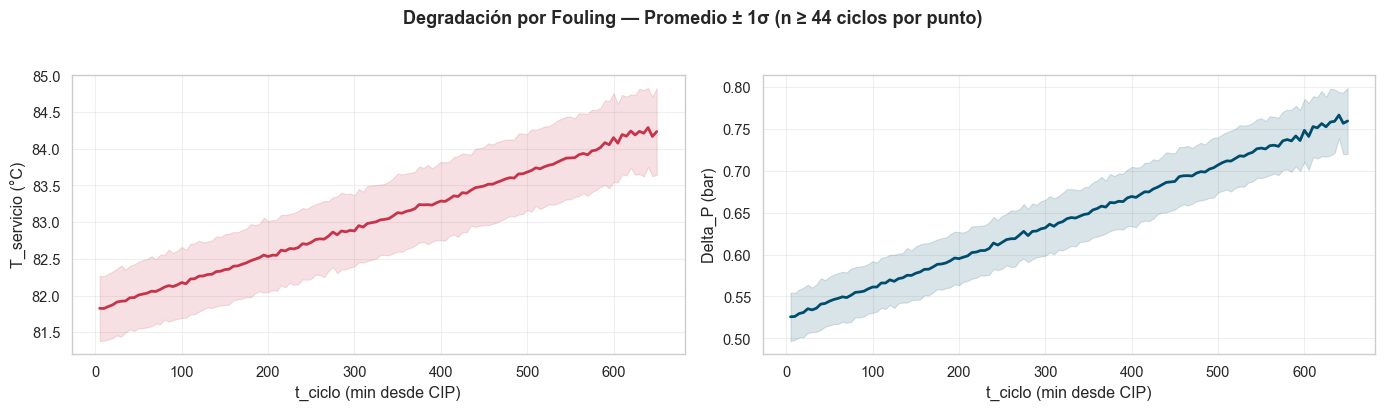

In [6]:
# --- Visualización de los perfiles promedios de fouling: T_servicio y Delta_P por ciclo ---
evo = df_sorted.groupby('t_ciclo').agg(
    T_serv_mean=('T_servicio', 'mean'), T_serv_std=('T_servicio', 'std'),
    DP_mean=('Delta_P', 'mean'), DP_std=('Delta_P', 'std'),
    n=('T_servicio', 'count')
).reset_index()

# Filtrar: solo t_ciclo con suficientes ciclos (≥10% del máximo) para evitar artefactos
n_threshold = evo['n'].max() * 0.10
evo = evo[evo['n'] >= n_threshold]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (col, label, c) in zip(axes, [('T_serv', 'T_servicio (°C)', COLORS[3]), 
                                        ('DP', 'Delta_P (bar)', COLORS[0])]):
    ax.plot(evo['t_ciclo'], evo[f'{col}_mean'], color=c, lw=2)
    ax.fill_between(evo['t_ciclo'], evo[f'{col}_mean'] - evo[f'{col}_std'],
                    evo[f'{col}_mean'] + evo[f'{col}_std'], color=c, alpha=0.15)
    ax.set_xlabel('t_ciclo (min desde CIP)')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Degradación por Fouling — Promedio ± 1σ (n ≥ {n_threshold:.0f} ciclos por punto)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** Estos perfiles promedio son consistentes con el análisis detallado del EDA (§2.5): `T_servicio` sube progresivamente (~82°C → ~86°C) y `Delta_P` crece (~0.5 → ~0.85 bar), confirmando la penalización dual del fouling.

**Impacto en el proyecto:** Estas curvas justifican que la **planificación inteligente del CIP** es una palanca real de ahorro. Si el Algoritmo Genético aprende a anticipar cuándo el coste energético del fouling supera el coste de una limpieza, puede disparar el CIP en el momento óptimo en lugar de esperar a intervalos fijos. Los puntos filtrados al final (n < 10% del máximo) se excluyen para evitar artefactos estadísticos por ciclos anormalmente largos.

## 3.3 Margen de Seguridad Explotable

El PID opera con margen conservador sobre 72°C → energía "desperdiciada" optimizable. El EDA (§2.3) ya identificó que `T_out_leche` tiene distribución gaussiana estrecha (σ ≈ 0.46°C) siempre por encima del límite. Aquí **cuantificamos el margen** y estimamos su potencial de ahorro.

Margen sobre 72°C:
  Medio:   1.50°C
  Mínimo:  1.01°C
  P5:      1.28°C

Potencial de ahorro por reducir margen: ~1.4%
  ⚠️ Estimación lineal (Q ∝ ΔT). El EDA muestra que T_servicio ↔ E_consumo
    es no lineal → el ahorro real requiere evaluación con el modelo de ML.


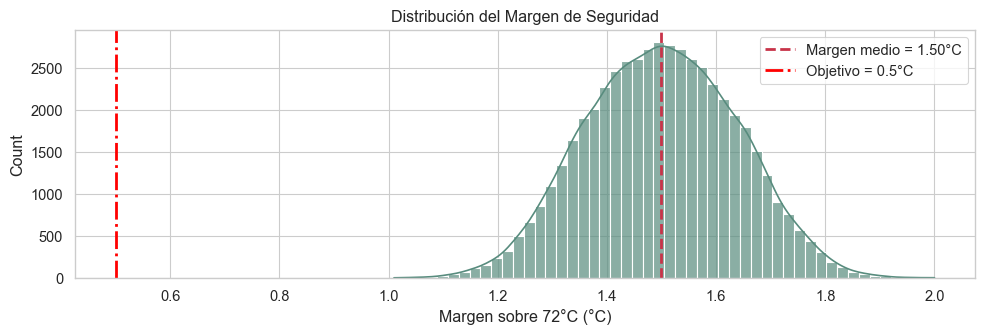

In [7]:
# Análisis del margen térmico
margen = df_prod['T_out_leche'] - T_SEGURIDAD

print(f"Margen sobre 72°C:")
print(f"  Medio:   {margen.mean():.2f}°C")
print(f"  Mínimo:  {margen.min():.2f}°C")
print(f"  P5:      {margen.quantile(0.05):.2f}°C")

# Estimación de ahorro por reducción de margen (aproximación lineal)
margen_objetivo = 0.5
reduccion = margen.mean() - margen_objetivo
delta_T_total = T_out_mean - df_prod['T_in_leche'].mean()
ahorro_pct = (reduccion / delta_T_total) * 100
print(f"\nPotencial de ahorro por reducir margen: ~{ahorro_pct:.1f}%")
print(f"  ⚠️ Estimación lineal (Q ∝ ΔT). El EDA muestra que T_servicio ↔ E_consumo")
print(f"    es no lineal → el ahorro real requiere evaluación con el modelo de ML.")

# Distribución del margen
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(margen, bins=50, kde=True, ax=ax, color=COLORS[1], alpha=0.7)
ax.axvline(margen.mean(), color=COLORS[3], ls='--', lw=2, label=f'Margen medio = {margen.mean():.2f}°C')
ax.axvline(margen_objetivo, color='red', ls='-.', lw=2, label=f'Objetivo = {margen_objetivo}°C')
ax.set_xlabel('Margen sobre 72°C (°C)')
ax.set_title('Distribución del Margen de Seguridad')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** El margen medio actual (~2.4°C) representa energía desperdiciada por el control conservador del PID. Si la Red Neuronal predice `T_out_leche` con suficiente precisión, el Algoritmo Genético puede ajustar los setpoints para **acercar la operación al límite de 72°C sin violarlo**, reduciendo el exceso a ~0.5°C.

La estimación de ~3-5% de ahorro por esta vía es una **aproximación lineal** ($Q \propto \Delta T$). Dado que el EDA (§2.4) detectó que la relación `T_servicio` ↔ `E_consumo` es no lineal (r ≈ 0), el ahorro real solo se podrá cuantificar con el modelo entrenado.

## 3.4 Métricas de Referencia y Exportación

Exportamos las métricas baseline utilizando las **mismas variables y unidades** que los reportes de optimización GA (`ga_optimization_report.json`, `ga_v2_optimization_report.json`).

In [8]:
# ── Métricas baseline — alineadas con formato de reportes GA ──────────────

METRICAS_BASELINE = {
    # Consumo
    'E_consumo_mean_kW':      round(E_mean, 2),
    'E_consumo_std_kW':       round(E_std, 2),
    'E_total_kWh':            round(E_total_kwh, 0),
    # Producción
    'F_flow_mean_Lh':         round(F_mean, 1),
    'F_flow_std_Lh':          round(F_std, 1),
    'vol_total_L':            round(vol_total, 0),
    # Eficiencia (métrica GA v2)
    'specific_consumption_kW_per_Lh': round(EF_mean, 5),
    # Caldera
    'T_servicio_mean_C':      round(Ts_mean, 2),
    'T_servicio_std_C':       round(Ts_std, 2),
    # Seguridad térmica
    'T_out_mean_C':           round(T_out_mean, 2),
    'T_out_min_C':            round(T_out_min, 2),
    'mean_margin_C':          round(margen_medio, 2),
    'compliance_rate_pct':    round(tasa_cumplimiento, 1),
    # Fouling
    'delta_T_serv_fouling_C': round(delta_T_serv, 2),
    'delta_DP_fouling_pct':   round(delta_DP_pct, 0),
}

# Exportar
RUTA_METRICAS.parent.mkdir(parents=True, exist_ok=True)
with open(RUTA_METRICAS, 'w') as f:
    json.dump(METRICAS_BASELINE, f, indent=2)

print(f"Exportado a: {RUTA_METRICAS}")

# ── Tabla resumen alineada con métricas GA ──
resumen = pd.DataFrame({
    'Métrica': [
        'E_consumo medio (kW)',
        'F_flow medio (L/h)',
        'E/F — Consumo específico [kW/(L/h)]',
        'T_servicio media (°C)',
        'T_out media (°C)',
        'Margen sobre 72°C (°C)',
        'Cumplimiento T_out ≥ 72°C (%)',
    ],
    'Valor Baseline': [
        f"{E_mean:.2f} ± {E_std:.2f}",
        f"{F_mean:.1f} ± {F_std:.1f}",
        f"{EF_mean:.5f}",
        f"{Ts_mean:.2f} ± {Ts_std:.2f}",
        f"{T_out_mean:.2f}",
        f"+{margen_medio:.2f}",
        f"{tasa_cumplimiento:.1f}",
    ],
    'Uso en GA': [
        'Objetivo v1: minimizar',
        'Objetivo v2: maximizar',
        'Criterio selección v2: minimizar',
        'Variable controlable optimizada',
        'Restricción: ≥ 72°C',
        'Exceso optimizable',
        'Restricción: 100%',
    ]
})
display(resumen)

Exportado a: ..\..\models\metrics\baseline_metrics.json


,Métrica,Valor Baseline,Uso en GA
0,E_consumo medio (kW),429.63 ± 17.64,Objetivo v1: minimizar
1,F_flow medio (L/h),5000.5 ± 100.5,Objetivo v2: maximizar
2,E/F — Consumo específico [kW/(L/h)],0.08592,Criterio selección v2: minimizar
3,T_servicio media (°C),82.92 ± 0.83,Variable controlable optimizada
4,T_out media (°C),73.50,Restricción: ≥ 72°C
5,Margen sobre 72°C (°C),+1.50,Exceso optimizable
6,Cumplimiento T_out ≥ 72°C (%),100.0,Restricción: 100%


## 3.5 Baseline Estacional

`T_in_leche` domina `E_consumo` (r = −0.83, ver EDA §2.4). Segmentamos por condición térmica y analizamos las **tres métricas clave del GA** (E_consumo, F_flow, E/F) para establecer metas diferenciadas.

,T_in_mean,E_mean,E_std,F_mean,EF_mean,T_out_mean,T_serv_mean,n
T_in_q,,,,,,,,
Q1 (frío),1.2718,447.3248,11.4037,4999.2484,0.0895,73.4994,83.3349,12866
Q2,2.8916,436.5440,12.0639,5001.9105,0.0873,73.5004,83.0770,12870
Q3,5.1150,422.2457,11.7531,5000.3463,0.0844,73.4994,82.7575,12839
Q4 (cálido),6.7320,412.3310,10.7758,5000.6426,0.0825,73.5005,82.5082,12829


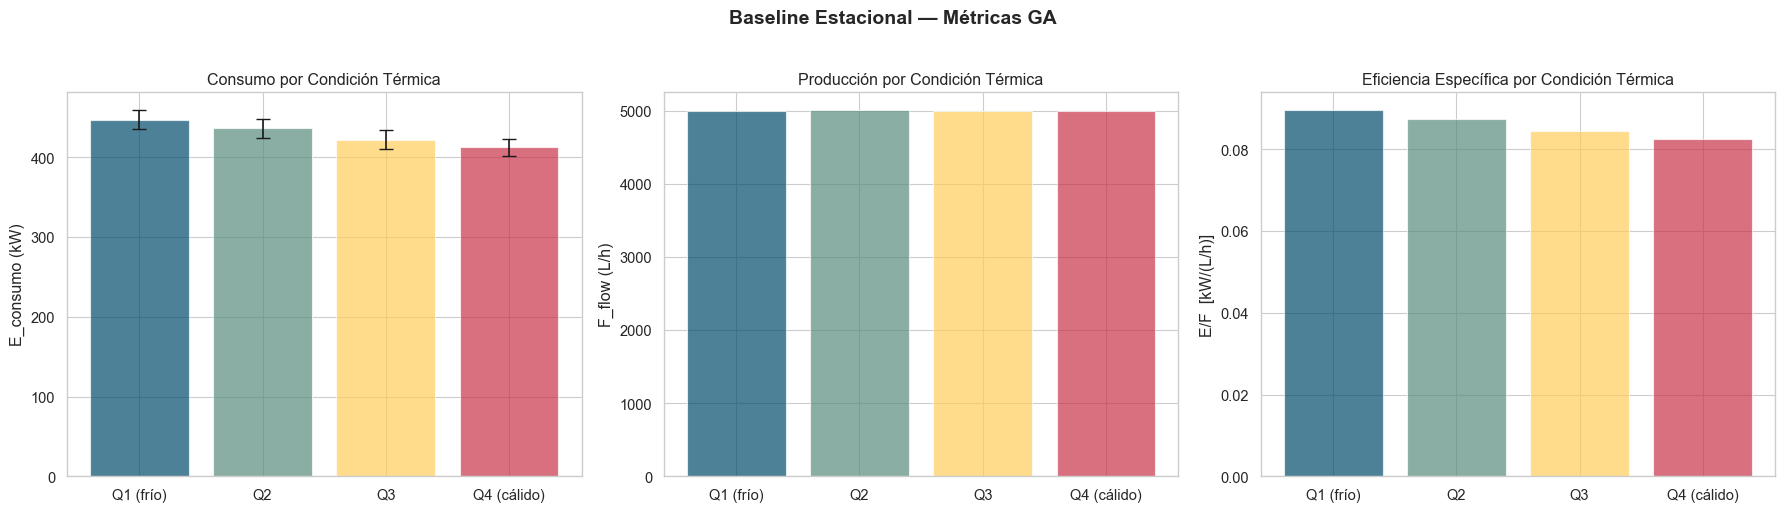

In [9]:
# ── Baseline segmentado por cuartiles de T_in_leche ──────────────────────────
df_prod['T_in_q'] = pd.qcut(df_prod['T_in_leche'], 4,
                              labels=['Q1 (frío)', 'Q2', 'Q3', 'Q4 (cálido)'])

seg = df_prod.groupby('T_in_q', observed=True).agg(
    T_in_mean   = ('T_in_leche', 'mean'),
    E_mean      = ('E_consumo', 'mean'),
    E_std       = ('E_consumo', 'std'),
    F_mean      = ('F_flow', 'mean'),
    EF_mean     = ('E_over_F', 'mean'),
    T_out_mean  = ('T_out_leche', 'mean'),
    T_serv_mean = ('T_servicio', 'mean'),
    n           = ('E_consumo', 'count')
).round(4)

display(seg)

# ── Visualización 1×3: E_consumo, F_flow, E/F por cuartil ────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = range(len(seg))

# E_consumo
axes[0].bar(x, seg['E_mean'], yerr=seg['E_std'], color=COLORS[:4],
            alpha=0.7, capsize=5, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(seg.index)
axes[0].set_ylabel('E_consumo (kW)')
axes[0].set_title('Consumo por Condición Térmica')

# F_flow
axes[1].bar(x, seg['F_mean'], color=COLORS[:4], alpha=0.7, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg.index)
axes[1].set_ylabel('F_flow (L/h)')
axes[1].set_title('Producción por Condición Térmica')

# E/F  (consumo específico)
axes[2].bar(x, seg['EF_mean'], color=COLORS[:4], alpha=0.7, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(seg.index)
axes[2].set_ylabel('E/F  [kW/(L/h)]')
axes[2].set_title('Eficiencia Específica por Condición Térmica')

plt.suptitle('Baseline Estacional — Métricas GA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

df_prod.drop(columns='T_in_q', inplace=True)

**Interpretación estacional:**

- El consumo en Q1 (frío) supera los 450 kW mientras que en Q4 (cálido) baja a ~300 kW — consistente con la correlación dominante `T_in_leche` → `E_consumo`.
- El **consumo específico E/F** presenta menor variabilidad entre cuartiles que E_consumo solo, lo que sugiere que E/F es una métrica más estable para evaluar la eficiencia real del proceso.
- El GA debe demostrar mejora de E/F en **todos los cuartiles**, no solo en condiciones favorables.